<a href="https://colab.research.google.com/github/bohdanakhobta/sales-performance-analysis/blob/main/sales_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data overview

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/MateAcademy/sources

Mounted at /content/drive
/content/drive/MyDrive/task


In [ ]:
# Uploading dataset
df_countries = pd.read_csv("countries.csv")
df_countries.head()

,account_id,visit_cnt,last_visit_date,revenue
0,680137,1,2020-11-01,20
1,676055,1,2020-11-02,40
2,674730,1,2020-11-02,20
3,681528,1,2020-11-02,50
4,670091,1,2020-11-02,40


The `countries` table contains information about country names where orders were placed, along with their corresponding regions and subregions.

In [ ]:
# Uploading dataset
df_events = pd.read_csv("events.csv")
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


The `events` table contains information related to order dates, shipping dates, sales channels, and product details, including quantity sold, price, and total cost.

In [ ]:
# Uploading dataset
df_products = pd.read_csv("products.csv")
df_products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


The `products` table contains information about product categories associated with the sold items.


Fields used to join the tables:
- `countries` – `events`: alpha-3 code and country code
- `events` – `products`: product_id and id

# Data cleaning

In [ ]:
print(df_countries.shape)
print(df_events.shape)
print(df_products.shape)

(249, 5)
(1330, 10)
(12, 2)


In [ ]:
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
df_events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
print(df_countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
print(df_countries.isna().sum() / df_countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
print(df_events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(df_events.isna().sum() / df_events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
print(df_products.isna().sum())

id           0
item_type    0
dtype: int64


In [ ]:
print(df_products.isna().sum() / df_products.shape[0] * 100)

id           0.0
item_type    0.0
dtype: float64


### Possible Causes of Missing Values

**`countries` table**: Some records represent territories or regions that do not have defined two-letter country codes or regional classifications. However, the alpha-3 field is populated for all records, as it is used as the primary identifier.

**`events` table**: Missing values may occur due to technical issues during data collection or import, as well as incomplete user input. In particular, missing values in the Country Code field may indicate that the country of the order was not identified, while missing values in Units Sold may suggest incomplete or canceled orders.

## Handling Missing Values

Missing values in the Country Code field will be filled with "Unknown", as they do not significantly affect the calculation of key metrics. Other missing values will be removed due to their relatively small proportion in the dataset.

In [ ]:
df_events["Country Code"] = df_events["Country Code"].fillna("Unknown")

In [ ]:
df_events = df_events.dropna()

In [ ]:
df_events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
df_countries = df_countries.dropna()

In [ ]:
df_countries.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


## Data Type Transformation

In [ ]:
df_events["Order Date"] = pd.to_datetime(df_events["Order Date"])
df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"])

In [ ]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


In [ ]:
#checking for duplicates in data
duplicate_rows_countries = df_countries.duplicated()
print(duplicate_rows_countries)
print(duplicate_rows_countries.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 247, dtype: bool
0


In [ ]:
#checking for duplicates in data
duplicate_rows_events = df_events.duplicated()
print(duplicate_rows_events)
print(duplicate_rows_events.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [ ]:
#checking for duplicates in data
duplicate_rows_products = df_products.duplicated()
print(duplicate_rows_products)
print(duplicate_rows_products.sum())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


In [ ]:
df_countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,247,247,247,247,247
unique,247,247,247,5,17
top,Afghanistan,AF,AFG,Africa,Latin America and the Caribbean
freq,1,1,1,59,52


In [ ]:
df_events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
df_products.describe()

,id
count,12.000000
mean,5802.166667
std,2937.985452
min,1270.000000
25%,2959.000000
50%,6659.500000
75%,8390.000000
max,8969.000000


No significant anomalies were identified in the dataset. Date ranges are consistent, and price and cost values are logically aligned. Potential outliers may exist in the Units Sold metric due to unusually high values.

# Data analysis and visualization

In [ ]:
events_countries = pd.merge(df_events, df_countries, left_on="Country Code", right_on="alpha-3", how="left")
print(events_countries)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
df = pd.merge(events_countries, df_products, left_on="Product ID", right_on="id", how="left")
print(df)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
df = df.drop(columns=["alpha-2", "alpha-3", "id"])

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,Europe,Southern Europe,Beverages


In [ ]:
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_"))


In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,region,sub_region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,Europe,Southern Europe,Beverages


In [ ]:
total_orders = df.shape[0] # Total amount of orders
total_orders

1328

In [ ]:
df["revenue"] = (df["units_sold"] * df["unit_price"]) # Total revenue

total_revenue = df["revenue"].sum()
total_revenue

np.float64(1702129408.21)

In [ ]:
df["profit"] = (df["units_sold"] * (df["unit_price"] - df["unit_cost"])) # Total profit

total_profit = df["profit"].sum()
total_profit


np.float64(501434459.0)

In [ ]:
df["profit"].mean() # Average profit

np.float64(377586.1890060241)

In [ ]:
countries_covered = df["country_code"].nunique() # Amount of covered countries
countries_covered

46

In [ ]:
avg_revenue_per_order = total_revenue / total_orders # Average revenue per order
avg_revenue_per_order

np.float64(1281723.9519653614)

In [ ]:
avg_profit_per_order = total_profit / total_orders # Average profit per order
avg_profit_per_order

np.float64(377586.1890060241)

In [ ]:
total_units_sold = df["units_sold"].sum() # Total units sold
total_units_sold

np.float64(6576524.0)

In [ ]:
product_categories = df["item_type"].nunique() # Amount of product categories
product_categories

12

In [ ]:
df["costs"] = (df["units_sold"] * df["unit_cost"]) # Total costs

In [ ]:
def add_bar_labels(ax, fmt="%.1f", padding=3, fontsize=9):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=fontsize)

In [ ]:
popularity_by_category = (df.groupby("item_type")["units_sold"].sum().sort_values(ascending=False)) # Popularity of categories

popularity_by_category

,units_sold
item_type,
Office Supplies,617641.0
Beverages,613133.0
Fruits,591672.0
Clothes,591385.0
Vegetables,582544.0
Baby Food,562706.0
Personal Care,557678.0
Cosmetics,533291.0
Meat,530380.0


In [ ]:
category_stats = (df.groupby("item_type").agg(total_revenue=("revenue", "sum"), costs=("costs", "sum"), total_profit=("profit", "sum"),
                                              total_units=("units_sold", "sum")).sort_values("total_revenue", ascending=False))

category_stats

,total_revenue,costs,total_profit,total_units
item_type,,,,
Office Supplies,4.022140e+08,3.242368e+08,77977176.25,617641.0
Household,2.942052e+08,2.212427e+08,72962466.77,440249.0
Cosmetics,2.331548e+08,1.404315e+08,92723306.17,533291.0
Meat,2.237620e+08,1.934243e+08,30337736.00,530380.0
Baby Food,1.436476e+08,8.970659e+07,53940997.16,562706.0
Cereal,9.579140e+07,5.453637e+07,41255034.15,465685.0
Vegetables,8.974673e+07,5.297073e+07,36776002.72,582544.0
Snacks,7.478861e+07,4.776119e+07,27027422.40,490160.0
Clothes,6.462655e+07,2.119524e+07,43431314.40,591385.0


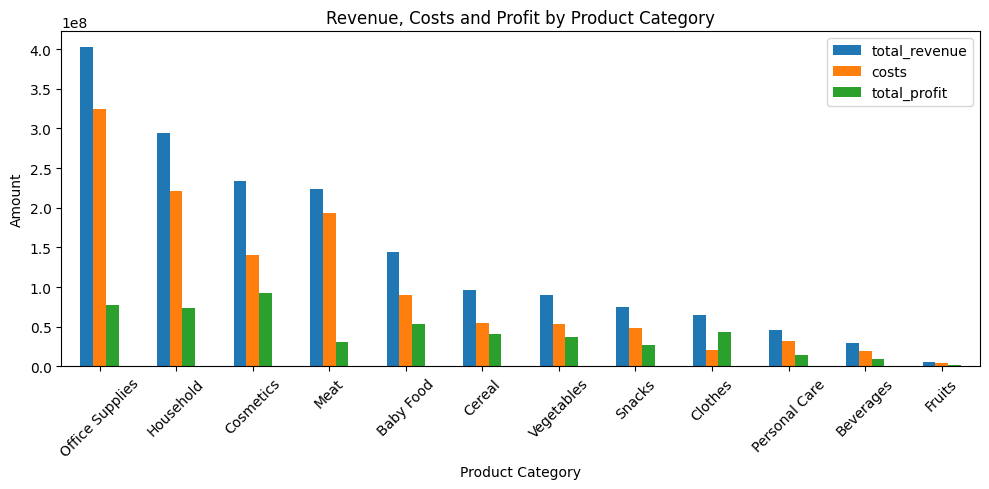

In [ ]:
category_stats[["total_revenue", "costs", "total_profit"]].plot(kind="bar", figsize=(10, 5))
plt.title("Revenue, Costs and Profit by Product Category")
plt.ylabel("Amount")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


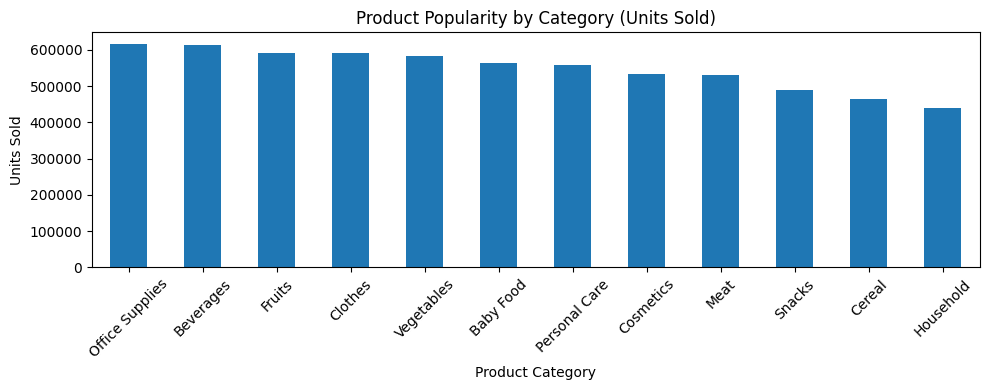

In [ ]:
popularity_by_category.plot(kind="bar",figsize=(10, 4))
plt.title("Product Popularity by Category (Units Sold)")
plt.ylabel("Units Sold")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
country_stats = df.groupby("name").agg(total_revenue=("revenue", "sum"),
                                        total_profit=("profit", "sum"),orders=("name", "count")).sort_values("total_revenue", ascending=False).head(10)

country_stats


,total_revenue,total_profit,orders
name,,,
Czech Republic,53543932.14,13635593.78,31
Ukraine,53252317.54,14804925.74,33
Bosnia and Herzegovina,50117508.49,13257602.77,33
Macedonia,49222085.25,13684099.95,32
San Marino,47883708.48,13792992.81,40
Andorra,47756693.17,15410036.63,40
Portugal,47172189.84,11345407.59,25
Malta,47145320.81,14610127.88,32
Russia,46051659.81,13267682.64,32


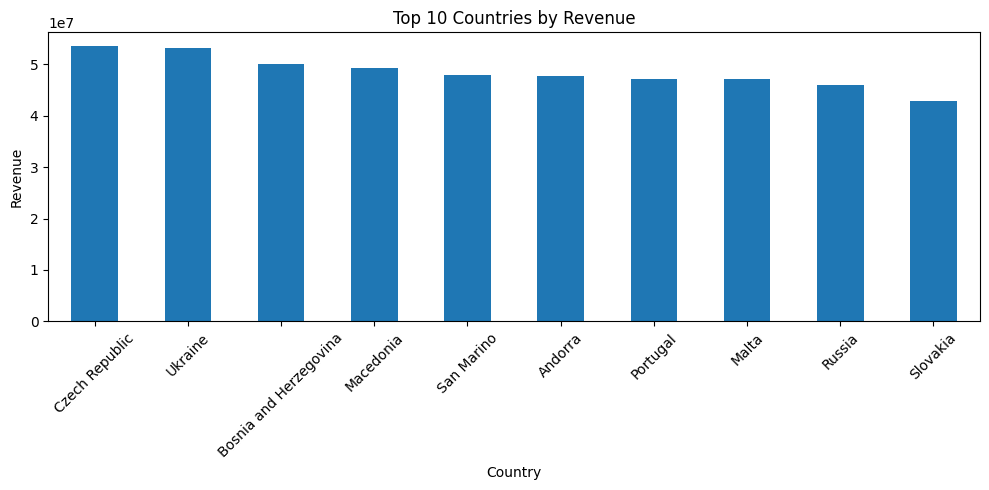

In [ ]:
country_stats["total_revenue"].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
popularity_by_country = (df.groupby("name")["units_sold"].sum().sort_values(ascending=False))

popularity_by_country.head(10)

,units_sold
name,
Macedonia,203078.0
San Marino,192228.0
Andorra,185686.0
Greece,176859.0
Malta,173641.0
Serbia,170369.0
Romania,166882.0
Russia,165954.0
Ukraine,164577.0


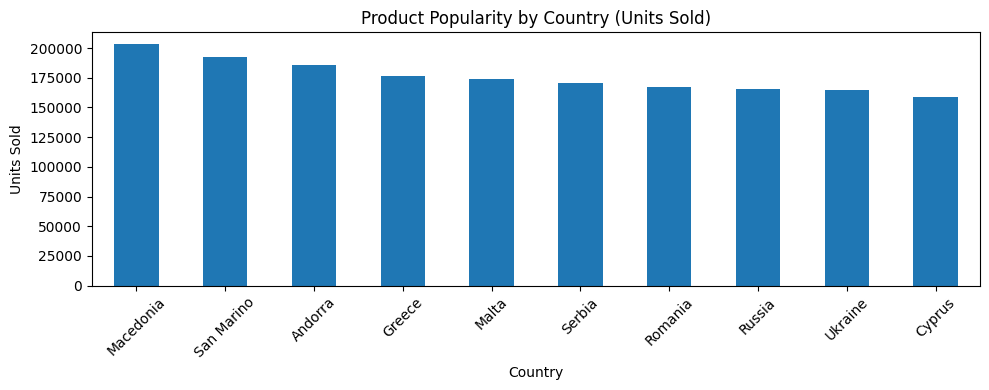

In [ ]:
popularity_by_country.head(10).plot(kind="bar", figsize=(10, 4))
plt.title("Product Popularity by Country (Units Sold)")
plt.ylabel("Units Sold")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
region_stats = (df.groupby("region").agg(revenue=("revenue", "sum"), costs=("costs", "sum"),
                                         profit=("profit", "sum"), total_units=("units_sold", "sum")))

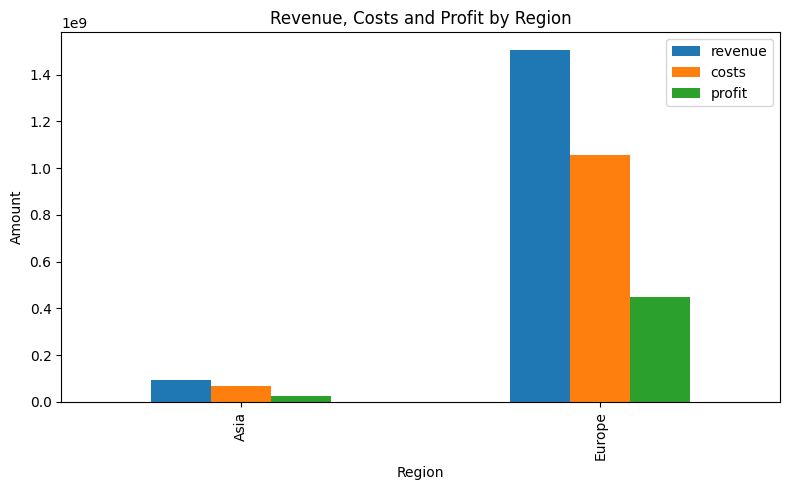

In [ ]:
region_stats[["revenue", "costs", "profit"]].plot(kind="bar", figsize=(8, 5))
plt.title("Revenue, Costs and Profit by Region")
plt.ylabel("Amount")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
popularity_by_region = (df.groupby("region")["units_sold"].sum().sort_values(ascending=False))

popularity_by_region


,units_sold
region,
Europe,5761244.0
Asia,410427.0


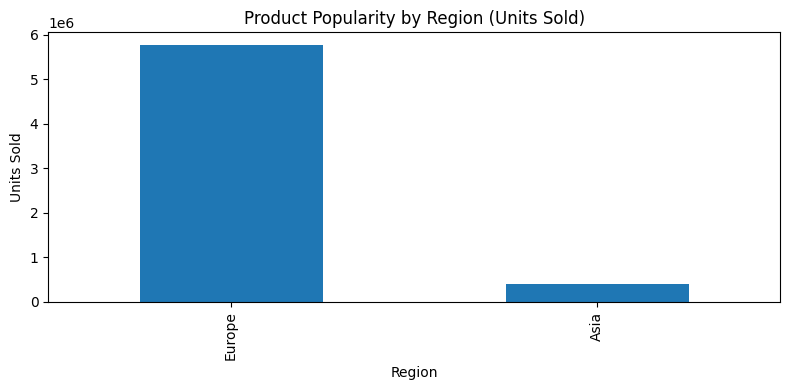

In [ ]:
popularity_by_region.plot(kind="bar", figsize=(8, 4))
plt.title("Product Popularity by Region (Units Sold)")
plt.ylabel("Units Sold")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
df["sales_channel"] = (df["sales_channel"].str.lower().astype(str).str.strip().str.lower())

In [ ]:
channel_stats = (df.groupby("sales_channel").agg(total_revenue=("revenue", "sum"), total_costs=("costs", "sum"),
                                                 total_profit=("profit", "sum"), total_units=("units_sold", "sum"), orders=("sales_channel", "count")))

channel_stats

,total_revenue,total_costs,total_profit,total_units,orders
sales_channel,,,,,
offline,8.717606e+08,6.182941e+08,2.534665e+08,3320363.0,665
online,8.303688e+08,5.824008e+08,2.479679e+08,3256161.0,663


In [ ]:
df["sales_channel"].unique()


array(['online', 'offline'], dtype=object)

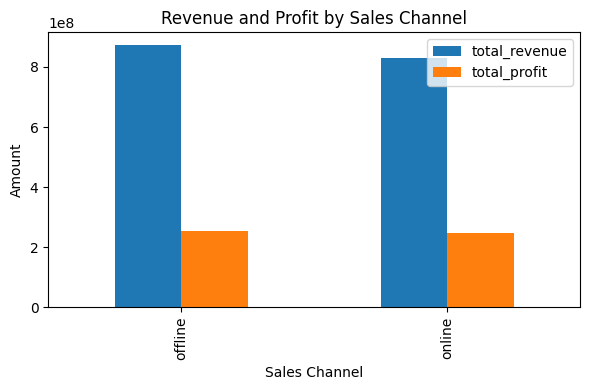

In [ ]:
channel_stats[["total_revenue", "total_profit"]].plot(kind="bar", figsize=(6, 4))
plt.title("Revenue and Profit by Sales Channel")
plt.ylabel("Amount")
plt.xlabel("Sales Channel")
plt.tight_layout()
plt.show()

In [ ]:
popularity_by_channel = (df.groupby("sales_channel")["units_sold"].sum())

popularity_by_channel

,units_sold
sales_channel,
offline,3320363.0
online,3256161.0


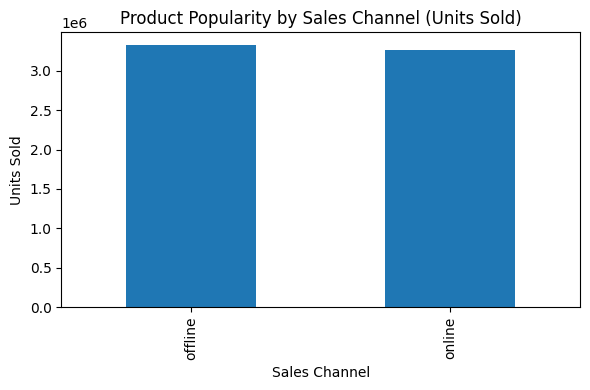

In [ ]:
popularity_by_channel.plot(kind="bar", figsize=(6, 4))
plt.title("Product Popularity by Sales Channel (Units Sold)")
plt.ylabel("Units Sold")
plt.xlabel("Sales Channel")
plt.tight_layout()
plt.show()


In [ ]:
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [ ]:
df["delivery_days"].describe()

,delivery_days
count,1328.000000
mean,24.786898
std,14.586041
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


In [ ]:
delivery_by_category = (df.groupby("item_type")["delivery_days"].agg(["mean", "median", "max"]).sort_values("mean", ascending=False))
delivery_by_category


,mean,median,max
item_type,,,
Cereal,27.184466,29.0,50
Office Supplies,26.707317,27.0,50
Baby Food,26.339286,28.5,50
Cosmetics,25.912281,28.0,50
Meat,25.909091,25.0,50
Snacks,25.543689,25.0,49
Fruits,24.419643,23.0,50
Beverages,24.123967,23.0,50
Household,23.938144,24.0,50


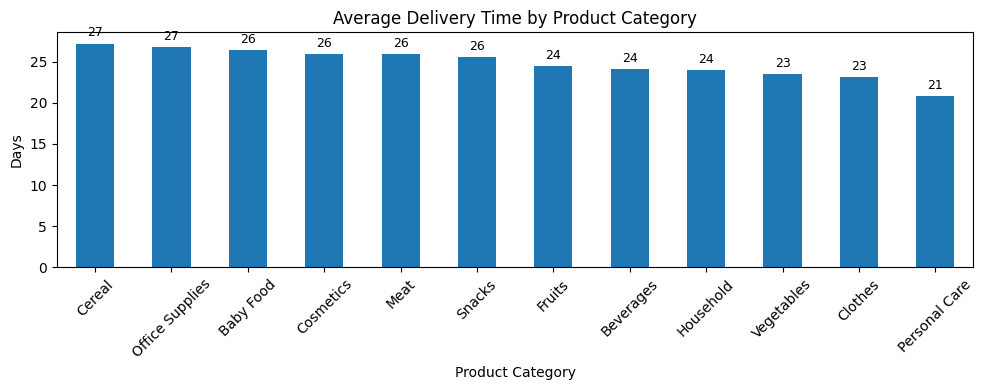

In [ ]:
ax = delivery_by_category["mean"].plot(kind="bar", figsize=(10, 4))
plt.title("Average Delivery Time by Product Category")
plt.ylabel("Days")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
add_bar_labels(ax, fmt="%.0f")
plt.tight_layout()
plt.show()


In [ ]:
top_countries = (df["name"].value_counts().head(10).index)

delivery_by_country = (df[df["name"].isin(top_countries)].groupby("name")["delivery_days"].mean().sort_values(ascending=False))

delivery_by_country


,delivery_days
name,
Russia,27.375000
Andorra,26.275000
Bosnia and Herzegovina,26.060606
Ukraine,25.757576
Czech Republic,25.225806
Romania,24.941176
Macedonia,23.218750
Greece,23.000000
San Marino,21.700000


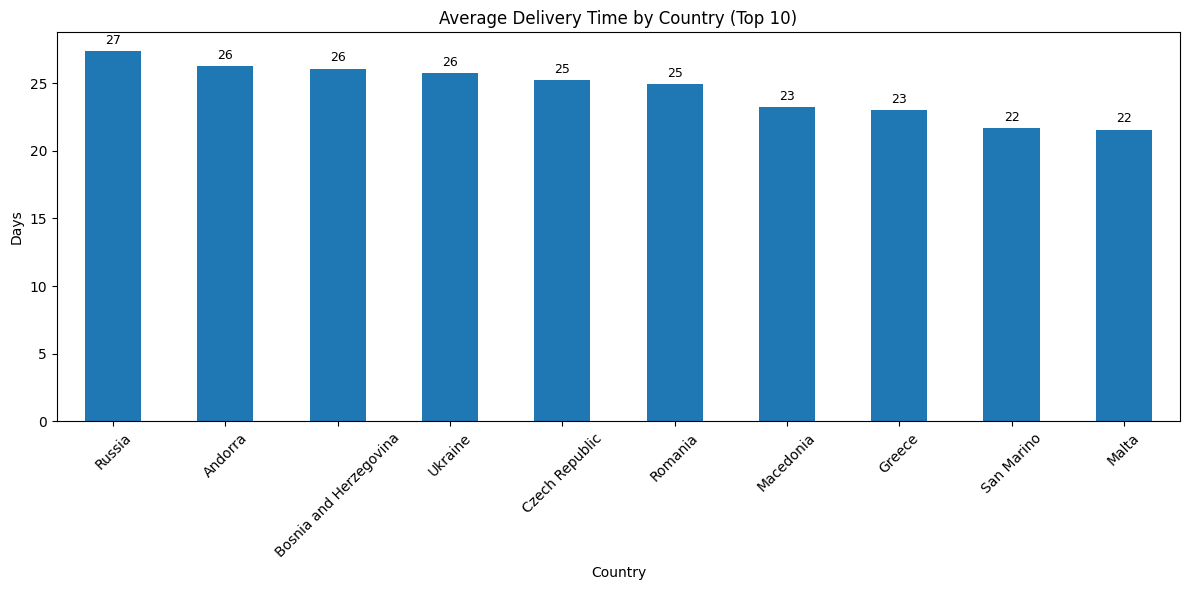

In [ ]:
ax = delivery_by_country.plot(kind="bar",figsize=(12, 6))
plt.title("Average Delivery Time by Country (Top 10)")
plt.ylabel("Days")
plt.xlabel("Country")
plt.xticks(rotation=45)
add_bar_labels(ax, fmt="%.0f")
plt.tight_layout()
plt.show()


In [ ]:
delivery_by_region = (df.groupby("region")["delivery_days"].mean().sort_values())

delivery_by_region


,delivery_days
region,
Europe,24.790378
Asia,26.085366


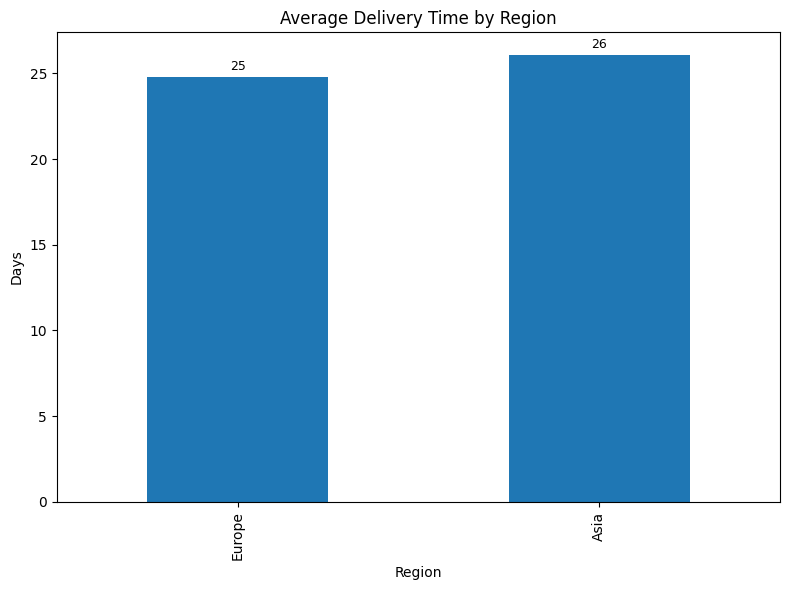

In [ ]:
ax = delivery_by_region.plot(kind="bar", figsize=(8, 6))
plt.title("Average Delivery Time by Region")
plt.ylabel("Days")
plt.xlabel("Region")
add_bar_labels(ax, fmt="%.0f")
plt.tight_layout()
plt.show()


In [ ]:
profit_by_delivery = (df.groupby("delivery_days")["profit"].mean())

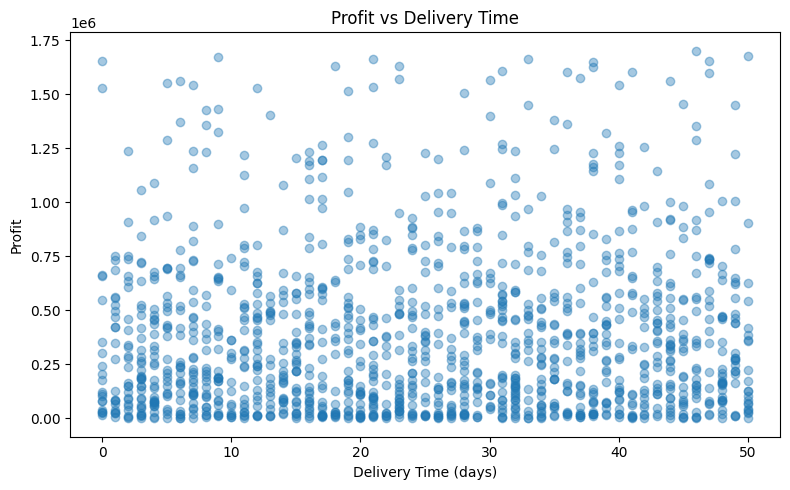

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["delivery_days"], df["profit"], alpha=0.4)

plt.title("Profit vs Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


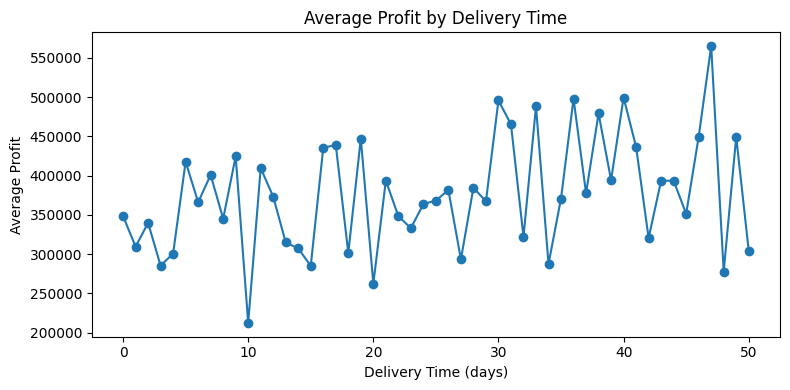

In [ ]:
ax = profit_by_delivery.plot(kind="line", figsize=(8, 4), marker="o")

plt.title("Average Profit by Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()


In [ ]:
df["order_month"] = (df["order_date"].dt.to_period("M").dt.to_timestamp())

In [ ]:
top_categories = (df.groupby("item_type")["revenue"].sum().sort_values(ascending=False).head(3).index)

category_time = (df[df["item_type"].isin(top_categories)].groupby(["order_month", "item_type"])["revenue"].sum().reset_index())

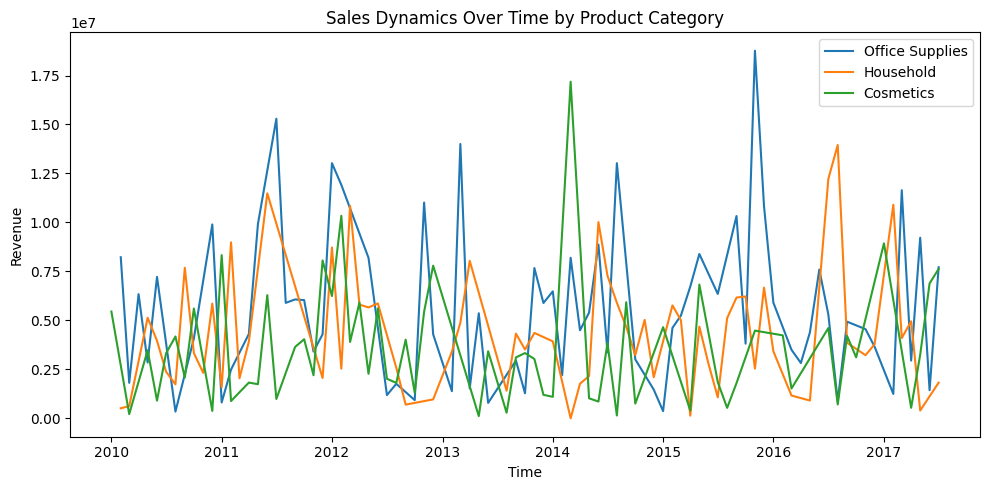

In [ ]:
plt.figure(figsize=(10, 5))
for category in top_categories:
    subset = category_time[category_time["item_type"] == category]
    plt.plot(subset["order_month"], subset["revenue"], label=category)
plt.title("Sales Dynamics Over Time by Product Category")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
top_countries = (df.groupby("name")["revenue"].sum().sort_values(ascending=False).head(3).index)

country_time = (df[df["name"].isin(top_countries)].groupby(["order_month", "name"])["revenue"].sum().reset_index())

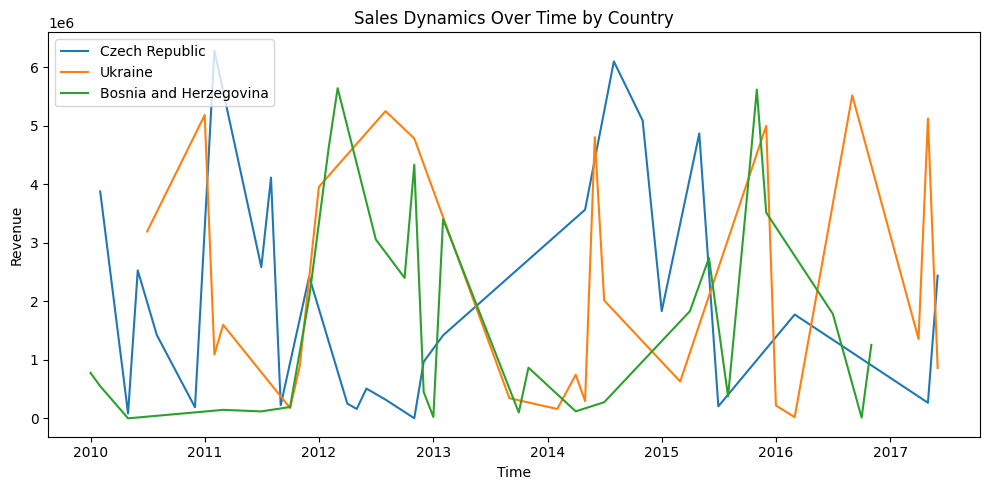

In [ ]:
plt.figure(figsize=(10, 5))
for country in top_countries:
    subset = country_time[country_time["name"] == country]
    plt.plot(subset["order_month"], subset["revenue"], label=country)
plt.title("Sales Dynamics Over Time by Country")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
region_time = (df.groupby(["order_month", "region"])["revenue"].sum().reset_index())

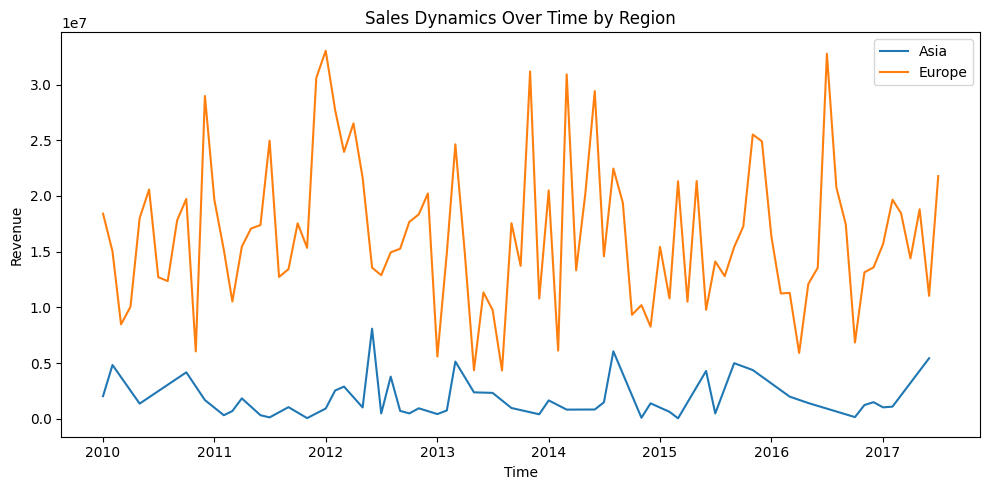

In [ ]:
plt.figure(figsize=(10, 5))
for region in region_time["region"].dropna().unique():
    subset = region_time[region_time["region"] == region]
    plt.plot(subset["order_month"], subset["revenue"], label=region)
plt.title("Sales Dynamics Over Time by Region")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


Sales trend analysis over time revealed overall seasonal fluctuations, as well as differences in growth rates across product categories, countries, and regions. The results indicate a heterogeneous demand structure.

In [ ]:
df["weekday"] = (df["order_date"].dt.day_name())

In [ ]:
df["weekday"].head()

,weekday
0,Wednesday
1,Thursday
2,Friday
3,Saturday
4,Saturday


In [ ]:
weekday_sales = (df.groupby("weekday")["revenue"].sum())

In [ ]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = weekday_sales.reindex(weekday_order)


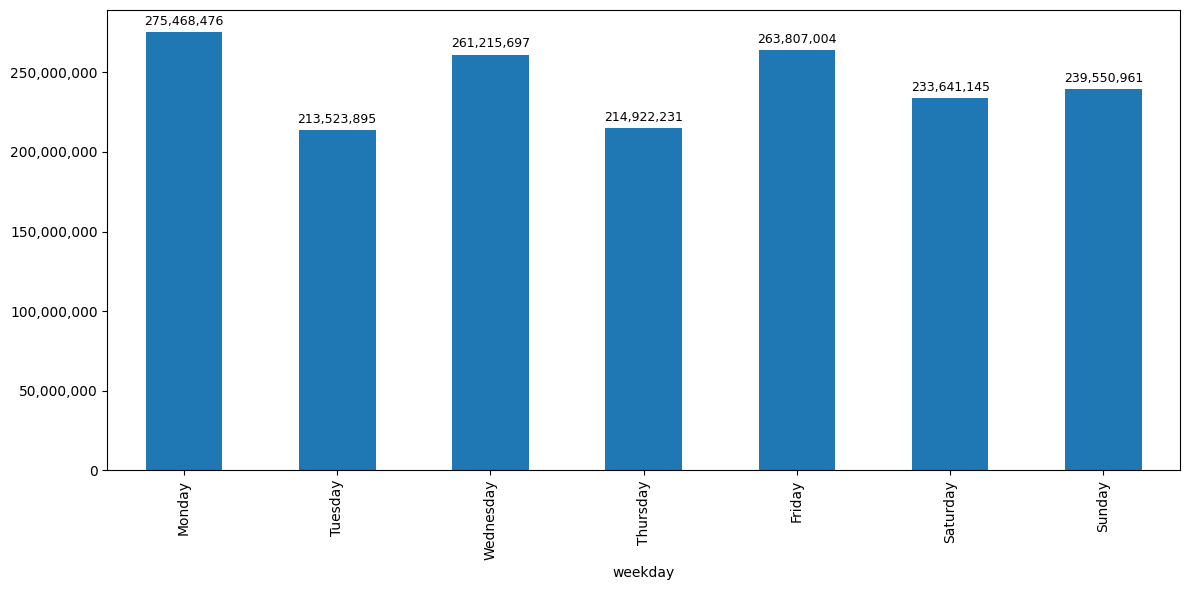

In [ ]:
import matplotlib.ticker as mtick

ax = weekday_sales.plot(kind="bar", figsize=(12, 6))

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

add_bar_labels(ax, fmt="{:,.0f}")

plt.tight_layout()
plt.show()

In [ ]:
weekday_category = (df.groupby(["weekday", "item_type"])["revenue"].sum().reset_index())

weekday_category["weekday"] = pd.Categorical(weekday_category["weekday"], categories=weekday_order,ordered=True)

weekday_category = weekday_category.sort_values("weekday")


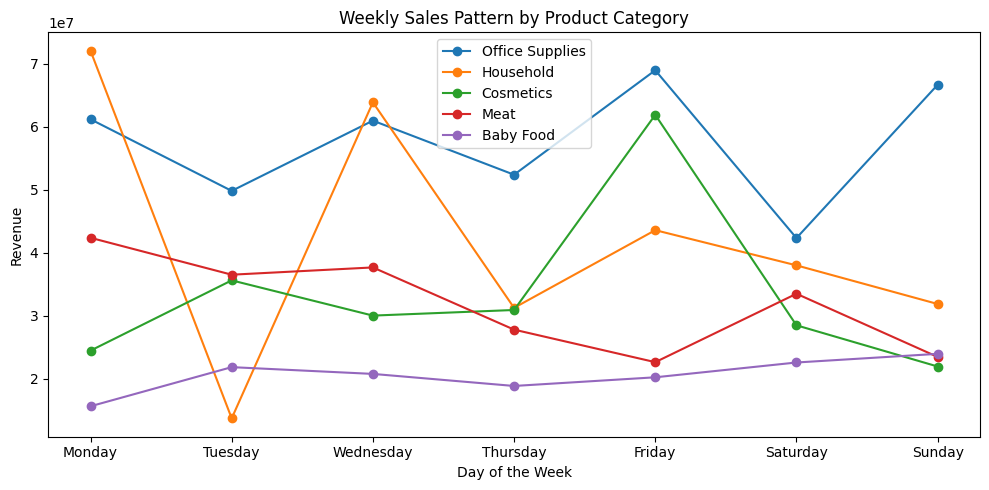

In [ ]:
top_categories = (df.groupby("item_type")["revenue"].sum().sort_values(ascending=False).head(5).index)

plt.figure(figsize=(10, 5))

for category in top_categories:
    subset = weekday_category[weekday_category["item_type"] == category]
    plt.plot(subset["weekday"],subset["revenue"],marker="o",label=category)

plt.title("Weekly Sales Pattern by Product Category")
plt.xlabel("Day of the Week")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


Overall sales levels differ between weekdays and weekends. Certain product categories exhibit consistent sales peaks on specific days of the week, suggesting intra-week seasonality. Other categories show a more evenly distributed sales pattern without pronounced weekly seasonality.

# Conclusions

The company operates across a wide geographic range and offers a diverse set of product categories.

The analysis shows that higher revenue does not necessarily translate into higher profit, indicating differences in product margins.

The average profit per order is lower than total profit, suggesting that the business relies on volume rather than high-margin transactions.

Popular categories by units sold or number of orders generate stable cash flow, even though some of them have lower profitability compared to less frequently sold items.

The company should consider scaling high-demand categories while also supporting less frequently sold but more profitable categories through marketing or improved availability.

The analysis indicates that a small number of countries generate the majority of revenue and profit. These countries represent key markets where logistics and marketing efforts should be concentrated.

Sales and profit are unevenly distributed across regions. Europe accounts for the largest share of revenue, suggesting that the company should reassess its sales strategy in Asia to improve performance.

Traffic channel analysis shows relatively small differences between channels, although offline traffic slightly dominates. The optimal strategy is to maintain a balanced approach rather than replacing one channel with another.

Delivery times vary across product categories and regions. Some categories have longer delivery times, likely due to product-specific characteristics. While logistics has an indirect impact on financial performance, longer delivery times may increase holding and operational costs. Improving delivery speed could also enhance customer satisfaction.

Sales exhibit clear fluctuations over time, indicating seasonality. Product categories and regions show different growth dynamics: some demonstrate steady growth, while others are more volatile. Demand forecasting and adapting marketing strategies to seasonal patterns are essential for improving business performance.